# Greater Pumpkin Commonwealth!


![gpc_logo](gpc_logo.png)


Source: [GPC Rules and Handbook 2021](https://gpc1.org/wp-content/uploads/2021/03/GPC-Rules-and-Handbook-2021.pdf)


Priscilla Pierce, Kailani Latimer, Michaela Dennis

The Great Pumpkin Commonwealth's (GPC) mission cultivates the hobby of growing giant pumpkins and other giant fruits throughout the world by establishing standards and regulations that ensure quality of fruit, fairness of competition, recognition of achievement, fellowship and education for all participating growers and weigh-off sites. 
Source: [GPC.org](http://gpc1.org/)


#### 1. Import packages and data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2021/2021-10-19/pumpkins.csv'                  # your file
df = pd.read_csv(url)

print(df.shape)
print(df.dtypes)

(28065, 14)
id                   object
place                object
weight_lbs           object
grower_name          object
city                 object
state_prov           object
country              object
gpc_site             object
seed_mother          object
pollinator_father    object
ott                  object
est_weight           object
pct_chart            object
variety              object
dtype: object


#### 2. Explore

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28065 entries, 0 to 28064
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 28065 non-null  object
 1   place              28065 non-null  object
 2   weight_lbs         28065 non-null  object
 3   grower_name        28065 non-null  object
 4   city               25286 non-null  object
 5   state_prov         28065 non-null  object
 6   country            28065 non-null  object
 7   gpc_site           28065 non-null  object
 8   seed_mother        19522 non-null  object
 9   pollinator_father  17758 non-null  object
 10  ott                24899 non-null  object
 11  est_weight         24899 non-null  object
 12  pct_chart          24899 non-null  object
 13  variety            724 non-null    object
dtypes: object(14)
memory usage: 3.0+ MB


![ott_measurement](ott_measurement.png)

Source: [GPC Rules and Handbook 2021](https://gpc1.org/wp-content/uploads/2021/03/GPC-Rules-and-Handbook-2021.pdf)


In [3]:
print(df.isnull().sum())

id                       0
place                    0
weight_lbs               0
grower_name              0
city                  2779
state_prov               0
country                  0
gpc_site                 0
seed_mother           8543
pollinator_father    10307
ott                   3166
est_weight            3166
pct_chart             3166
variety              27341
dtype: int64


#### Q: is there a correlation between size and weight of pumpkins and place grown

#### 3. Start cleaning, 4. filtering, 5. Sorting, and 6. Transforming

In [4]:
# filter pumpkin type in id to just F and P (field and giant)

f_pumpkin = df[df['id'].str.contains('F')]
f_pumpkin = f_pumpkin[~f_pumpkin['country'].str.contains('Unknown')] # filter out unknown countries
p_pumpkin = df[df['id'].str.contains('P')]
p_pumpkin = p_pumpkin[~p_pumpkin['country'].str.contains('Unknown')] # filter out unknown countries
p_pumpkin.info() # check it out

<class 'pandas.core.frame.DataFrame'>
Index: 15964 entries, 496 to 27278
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 15964 non-null  object
 1   place              15964 non-null  object
 2   weight_lbs         15964 non-null  object
 3   grower_name        15964 non-null  object
 4   city               14395 non-null  object
 5   state_prov         15964 non-null  object
 6   country            15964 non-null  object
 7   gpc_site           15964 non-null  object
 8   seed_mother        11539 non-null  object
 9   pollinator_father  10804 non-null  object
 10  ott                15964 non-null  object
 11  est_weight         15964 non-null  object
 12  pct_chart          15964 non-null  object
 13  variety            0 non-null      object
dtypes: object(14)
memory usage: 1.8+ MB


In [5]:
# bring the two pumpkin types back together with concat
big_pumpkin = pd.concat([f_pumpkin, p_pumpkin], ignore_index=True)
big_pumpkin.isnull().sum() # check for missing data

id                       0
place                    0
weight_lbs               0
grower_name              0
city                  1836
state_prov               0
country                  0
gpc_site                 0
seed_mother           5476
pollinator_father     6377
ott                      0
est_weight               0
pct_chart                0
variety              18720
dtype: int64

In [6]:
# make year col and make it datetime
big_pumpkin['year'] = big_pumpkin['id'].str[0:4]
big_pumpkin['year'] = pd.to_datetime(big_pumpkin['year'])
big_pumpkin['year'] = big_pumpkin['year'].dt.year # make year into a date

### Field pumpkin

![field_pumpkin](field_pumpkin.png)

Source: [GPC Rules and Handbook 2021](https://gpc1.org/wp-content/uploads/2021/03/GPC-Rules-and-Handbook-2021.pdf)

### Giant pumpkin
![giant_pumpkin_example](giant_pumpkin_example.png)


In [ ]:
# make type (giant vs field) using id col
big_pumpkin['Type'] = big_pumpkin['id'].str[5:6]

In [8]:
big_pumpkin # check it out

,id,place,weight_lbs,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,pct_chart,variety,year,Type
0,2013-F,1,154.50,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.00,20.0,NaN,2013,F
1,2013-F,2,146.50,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.00,-3.0,NaN,2013,F
2,2013-F,3,145.00,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.00,26.0,NaN,2013,F
3,2013-F,4,140.80,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.00,-7.0,NaN,2013,F
4,2013-F,5,139.00,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.00,0.0,NaN,2013,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18715,2021-P,DMG,382.70,"Ardron, Simon",Bracknell,England,United Kingdom,Wargrave Nursery Giant Pumpkin Weigh-off,NaN,NaN,0.0,0.00,0.0,NaN,2021,P
18716,2021-P,DMG,367.00,"Desautels, Jose Pierre",St Alexandre,Quebec,Canada,Potirothon de Gentilly,NaN,NaN,0.0,0.00,0.0,NaN,2021,P
18717,2021-P,DMG,276.70,"Boschi, Valerio",Pontedera,Tuscany,Italy,Campionato dello Zuccone,230 Geddes,Self,226.0,267.00,4.0,NaN,2021,P
18718,2021-P,DMG,109.00,"Decola, Gregg",New Haven,Connecticut,United States,Durham Fair Weigh-Off,NaN,NaN,0.0,0.00,0.0,NaN,2021,P


In [ ]:
# drop id col and variety
# we don't do that here!!! get em banned.
big_pumpkin = big_pumpkin.drop(columns = 'id')
big_pumpkin = big_pumpkin.drop(columns = 'variety')

In [10]:
big_pumpkin.head() # check it out again

,place,weight_lbs,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,pct_chart,year,Type
0,1,154.50,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.00,20.0,2013,F
1,2,146.50,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.00,-3.0,2013,F
2,3,145.00,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.00,26.0,2013,F
3,4,140.80,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.00,-7.0,2013,F
4,5,139.00,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.00,0.0,2013,F


In [11]:
# clean the rows that are place holders to separate pumpkin types

big_pumpkin = big_pumpkin[~big_pumpkin['weight_lbs'].str.contains('Entries')]
big_pumpkin # check it out !!!

,place,weight_lbs,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,pct_chart,year,Type
0,1,154.50,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.00,20.0,2013,F
1,2,146.50,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.00,-3.0,2013,F
2,3,145.00,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.00,26.0,2013,F
3,4,140.80,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.00,-7.0,2013,F
4,5,139.00,"Barlow, John",NaN,Wisconsin,United States,Stillwater Harvestfest,130.5 McKinnon,open,0.0,0.00,0.0,2013,F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18714,DMG,392.50,"Reinhart, Seth",Lake Oswego,Oregon,United States,Baumans Farm Giant Pumpkin Weigh-off,826 Williams,Self,245.0,337.00,16.0,2021,P
18715,DMG,382.70,"Ardron, Simon",Bracknell,England,United Kingdom,Wargrave Nursery Giant Pumpkin Weigh-off,NaN,NaN,0.0,0.00,0.0,2021,P
18716,DMG,367.00,"Desautels, Jose Pierre",St Alexandre,Quebec,Canada,Potirothon de Gentilly,NaN,NaN,0.0,0.00,0.0,2021,P
18717,DMG,276.70,"Boschi, Valerio",Pontedera,Tuscany,Italy,Campionato dello Zuccone,230 Geddes,Self,226.0,267.00,4.0,2021,P


In [12]:
# change the name of type to be the scientific name of pumpkins

big_pumpkin['Type'] = big_pumpkin['Type'].replace({'F':'Cucurbita pepo', 'P':'Cucurbita maxima'})

In [13]:
# clean out the commas to get ready to convert strings to floats

pumpkin_clean = big_pumpkin
pumpkin_clean['weight_lbs'] = pumpkin_clean['weight_lbs'].str.replace(",", "")
pumpkin_clean['est_weight'] = pumpkin_clean['est_weight'].str.replace(",", "")
pumpkin_clean['ott'] = pumpkin_clean['ott'].str.replace(",", "")

pumpkin_clean.isnull().sum() # check.

place                   0
weight_lbs              0
grower_name             0
city                 1836
state_prov              0
country                 0
gpc_site                0
seed_mother          5476
pollinator_father    6377
ott                     0
est_weight              0
pct_chart               0
year                    0
Type                    0
dtype: int64

In [14]:
# convert to floats
pumpkin_clean['weight_lbs'] = pumpkin_clean['weight_lbs'].astype(float)
pumpkin_clean['est_weight'] = pumpkin_clean['est_weight'].astype(float)
pumpkin_clean['ott'] = pumpkin_clean['ott'].astype(float)

pumpkin_clean.info() # check check check

<class 'pandas.core.frame.DataFrame'>
Index: 18702 entries, 0 to 18718
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   place              18702 non-null  object 
 1   weight_lbs         18702 non-null  float64
 2   grower_name        18702 non-null  object 
 3   city               16866 non-null  object 
 4   state_prov         18702 non-null  object 
 5   country            18702 non-null  object 
 6   gpc_site           18702 non-null  object 
 7   seed_mother        13226 non-null  object 
 8   pollinator_father  12325 non-null  object 
 9   ott                18702 non-null  float64
 10  est_weight         18702 non-null  float64
 11  pct_chart          18702 non-null  object 
 12  year               18702 non-null  int32  
 13  Type               18702 non-null  object 
dtypes: float64(3), int32(1), object(10)
memory usage: 2.1+ MB


In [15]:
# filter out the data that was incorrectly input (no pumpkins have an ott of 0 inches
# or over 1000 in)
pumpkin_clean = pumpkin_clean[(pumpkin_clean['ott'] > 1) & (pumpkin_clean['ott'] < 1000)]
pumpkin_clean

,place,weight_lbs,grower_name,city,state_prov,country,gpc_site,seed_mother,pollinator_father,ott,est_weight,pct_chart,year,Type
0,1,154.5,"Ellenbecker, Todd & Sequoia",Gleason,Wisconsin,United States,Nekoosa Giant Pumpkin Fest,209 Werner,Self,184.0,129.0,20.0,2013,Cucurbita pepo
1,2,146.5,"Razo, Steve",New Middletown,Ohio,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,150.5 Snyder,NaN,194.0,151.0,-3.0,2013,Cucurbita pepo
2,3,145.0,"Ellenbecker, Todd & Sequoia",Glenson,Wisconsin,United States,Mishicot Pumpkin Fest,209 Werner,103 Mackinnon,177.0,115.0,26.0,2013,Cucurbita pepo
3,4,140.8,"Martin, Margaret & Glen",Combined Locks,Wisconsin,United States,Cedarburg Wine and Harvest Festival,109 Martin '12,209 Werner '12,194.0,151.0,-7.0,2013,Cucurbita pepo
5,5,139.0,"Werner, Quinn",Saegartown,Pennsylvania,United States,Ohio Valley Giant Pumpkin Growers Weigh-off,209 Werner,NaN,190.0,141.0,-1.0,2013,Cucurbita pepo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18709,DMG,612.0,"Dickson, Kyley",Knoxville,Tennessee,United States,Tennessee Valley Fair,Dill,Self,297.0,605.0,1.0,2021,Cucurbita maxima
18710,DMG,566.0,"Bucks, Olivia",Beaverton,Oregon,United States,Baumans Farm Giant Pumpkin Weigh-off,873.5 Wessling,Self,290.0,560.0,1.0,2021,Cucurbita maxima
18711,DMG,521.2,"Dentzer, Marc",Beringen,Other,Luxembourg,Deutsche Meisterschaft im Kurbiswiegen,NaN,NaN,315.0,718.0,-27.0,2021,Cucurbita maxima
18714,DMG,392.5,"Reinhart, Seth",Lake Oswego,Oregon,United States,Baumans Farm Giant Pumpkin Weigh-off,826 Williams,Self,245.0,337.0,16.0,2021,Cucurbita maxima


## OTT and weight correlation

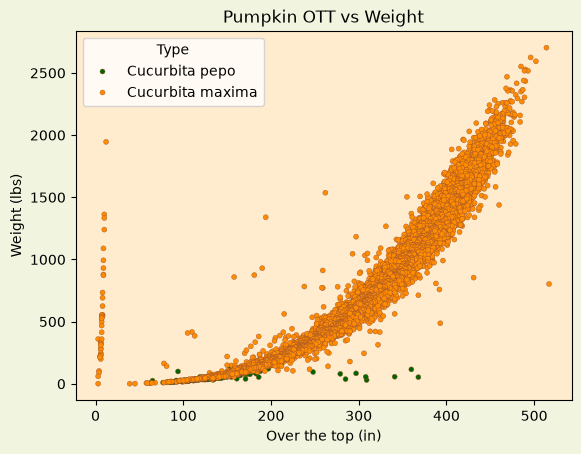

In [16]:
# scatterplot for ott vs weight
fig, ax = plt.subplots()
sns.scatterplot(
    data=pumpkin_clean,
    x='ott', y='weight_lbs', 
    hue='Type', 
    palette=['darkgreen', 'darkorange'], edgecolor='sienna', s=13)

plt.xlabel('Over the top (in)')
plt.ylabel('Weight (lbs)')
plt.title('Pumpkin OTT vs Weight')
ax.set_facecolor('blanchedalmond')
fig.patch.set_facecolor('#f1f5e0')
plt.show()

## Pumpkin means!

In [17]:
# create 2 new dfs for each of the pumpkin types so we can
#  visualize them independently as well

f_pumpkin_clean = pumpkin_clean[pumpkin_clean['Type'] == 'Cucurbita pepo']
p_pumpkin_clean = pumpkin_clean[pumpkin_clean['Type'] == 'Cucurbita maxima']


In [ ]:
# make mean weights of each to plot

mean_weight_f = f_pumpkin_clean.groupby('country')['weight_lbs'].mean().sort_values(ascending=False)
mean_weight_f.round(2)
mean_weight_p = p_pumpkin_clean.groupby('country')['weight_lbs'].mean().sort_values(ascending=False)
mean_weight_p.round(2)

country
New Zealand        1350.00
United Kingdom     1343.28
Switzerland        1329.73
Belgium            1074.31
United States       881.46
Poland              880.03
Canada              853.93
Spain               791.47
Slovenia            790.37
France              716.24
Austria             715.48
Italy               681.99
Germany             600.27
The Netherlands     578.90
Luxembourg          521.20
Portugal            456.41
Finland             405.83
Name: weight_lbs, dtype: float64

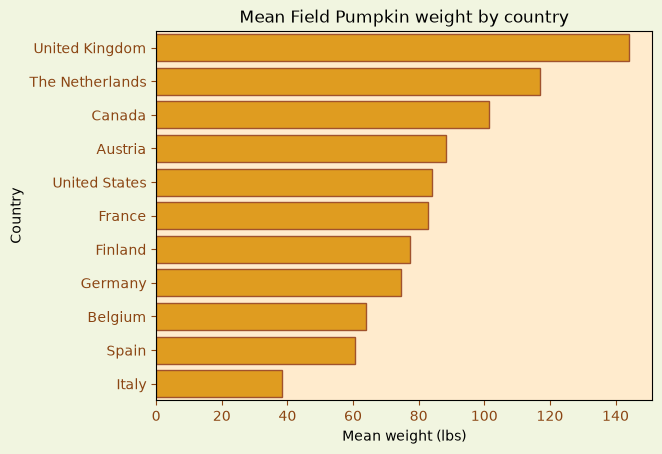

In [19]:
# field pumpkins
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
sns.barplot(x=mean_weight_f.values, y=mean_weight_f.index, color='orange', edgecolor='sienna')

plt.xlabel('Mean weight (lbs)', color='black')
plt.ylabel('Country', color='black')
plt.title('Mean Field Pumpkin weight by country')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
ax.set_facecolor('blanchedalmond')
fig.patch.set_facecolor('#f1f5e0')
plt.show()

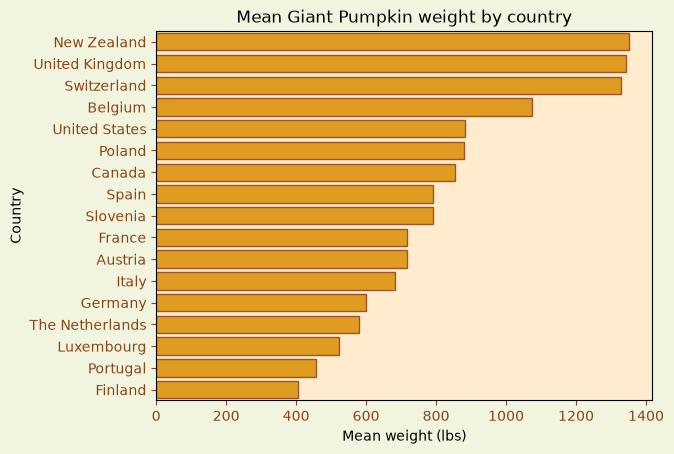

In [20]:
# giant pumpkins

fig, ax = plt.subplots()

sns.barplot(x=mean_weight_p.values, y=mean_weight_p.index, color='orange', edgecolor='sienna')

plt.xlabel('Mean weight (lbs)', color='black')
plt.ylabel('Country', color='black')
plt.title('Mean Giant Pumpkin weight by country', color='black')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
ax.set_facecolor('blanchedalmond')
fig.patch.set_facecolor('#f1f5e0')
plt.show()

## Pumpkin size by year

In [ ]:
# take the means by year and keep the type
yearly_means = pumpkin_clean.groupby(['year', 'Type'])['weight_lbs'].mean().sort_values(ascending = False).reset_index()
yearly_means.round(2)

,year,Type,weight_lbs
0,2020,Cucurbita maxima,879.61
1,2017,Cucurbita maxima,874.32
2,2016,Cucurbita maxima,873.61
3,2021,Cucurbita maxima,853.33
4,2018,Cucurbita maxima,851.77
5,2015,Cucurbita maxima,840.41
6,2014,Cucurbita maxima,830.69
7,2019,Cucurbita maxima,808.80
8,2013,Cucurbita maxima,741.08
9,2014,Cucurbita pepo,96.81


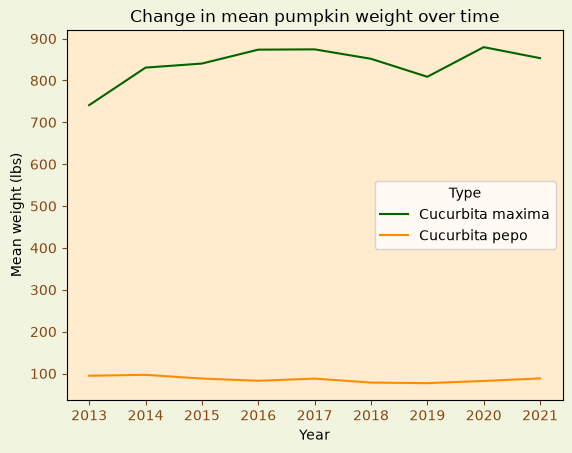

In [22]:
# plot!

fig, ax = plt.subplots()

sns.lineplot(
    data = yearly_means,
    x = 'year', 
    y = 'weight_lbs', 
    hue ='Type',
    palette=['darkgreen', 'darkorange'])
plt.xlabel('Year', color='black')
plt.ylabel('Mean weight (lbs)', color='black')
plt.title('Change in mean pumpkin weight over time', color='black')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
ax.set_facecolor('blanchedalmond')
fig.patch.set_facecolor('#f1f5e0')
plt.show()

## Cucurbita maxima Growers

In [43]:
# count of entries each year by grower for Cucurbita maxima
maxima = big_pumpkin[big_pumpkin['Type'] == 'Cucurbita maxima']

growers_maxima = maxima.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='count'
)

growers_maxima = growers_maxima.reset_index()

# make column that shows sum of count of entries per year by grower
growers_maxima['total_entries'] = growers_maxima.sum(axis=1, numeric_only=True)

# rename year columns to be more descriptive
growers_maxima = growers_maxima.rename(
    columns={
        2013:'2013_entries', 
        2014:'2014_entries', 
        2015:'2015_entries', 
        2016:'2016_entries', 
        2017:'2017_entries', 
        2018:'2018_entries', 
        2019:'2019_entries', 
        2020:'2020_entries', 
        2021:'2021_entries'})

In [44]:
# mean pumpkin weight in lbs each year by grower for maxima
mean_weight_maxima = maxima.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='mean'
)

mean_weight_maxima = mean_weight_maxima.reset_index()

# make column that shows mean weight of pumpkins across all years by grower
mean_weight_maxima['mean_all_years'] = mean_weight_maxima.mean(axis=1, numeric_only=True)

# rename year columns to be more descriptive
mean_weight_maxima = mean_weight_maxima.rename(
    columns={
        2013:'2013_mean_wt_lb', 
        2014:'2014_mean_wt_lb', 
        2015:'2015_mean_wt_lb', 
        2016:'2016_mean_wt_lb', 
        2017:'2017_mean_wt_lb', 
        2018:'2018_mean_wt_lb', 
        2019:'2019_mean_wt_lb', 
        2020:'2020_mean_wt_lb', 
        2021:'2021_mean_wt_lb'})

In [45]:
# max pumpkin weight in lbs each year by grower for maxima
max_weight_maxima = maxima.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='max'
)

max_weight_maxima = max_weight_maxima.reset_index()

# make column that shows max weight across all years by grower
max_weight_maxima['max_all_years'] = max_weight_maxima.max(axis=1, numeric_only=True)

# rename year columns to be more descriptive
max_weight_maxima = max_weight_maxima.rename(
    columns={
        2013:'2013_max_wt_lb', 
        2014:'2014_max_wt_lb', 
        2015:'2015_max_wt_lb', 
        2016:'2016_max_wt_lb', 
        2017:'2017_max_wt_lb', 
        2018:'2018_max_wt_lb', 
        2019:'2019_max_wt_lb', 
        2020:'2020_max_wt_lb', 
        2021:'2021_max_wt_lb'})

In [46]:
# Outer merge growers_maxima and mean_weight_maxima

growers_maxima_mean = pd.merge(growers_maxima, mean_weight_maxima, on='grower_name', how='outer')
growers_maxima_mean.shape

(6498, 21)

In [47]:
# Outer merge growers_maxima_mean and max_weight_maxima

growers_maxima_mean_max = pd.merge(growers_maxima_mean, max_weight_maxima, on='grower_name', how='outer')
growers_maxima_mean_max.shape

(6498, 31)

In [48]:
# Rank Cucurbita maxima growers by highest number of total entries and show top 5

maxima_growers_ranked = growers_maxima_mean_max.sort_values('total_entries', ascending=False)
maxima_growers_ranked[['grower_name','total_entries', 'mean_all_years','max_all_years']].head(5)

year,grower_name,total_entries,mean_all_years,max_all_years
4470,"Platte, Joe",47.0,1387.043122,2110.0
5156,"Sherwood, Jim",42.0,1443.657738,1868.0
6227,"Wolf, Andy",41.0,1255.222222,2365.0
1844,"Gansert, Norman",41.0,843.260185,1625.0
3857,"Miller, Gary",38.0,1334.153704,1985.0


In [49]:
# Rank Cucurbita maxima growers by heaviest pumpkin entered (lbs) and show top 5
maxima_growers_heaviest = growers_maxima_mean_max.sort_values('max_all_years', ascending=False)
maxima_growers_heaviest[['grower_name','total_entries', 'mean_all_years','max_all_years']].head(5)

year,grower_name,total_entries,mean_all_years,max_all_years
1180,"Cutrupi, Stefano",21.0,1752.337037,2702.9
6147,"Willemijns, Mathias",8.0,1984.530556,2624.6
4309,"Paton, Ian & Stuart",18.0,1910.883333,2593.7
3779,"Mendi, Ruben",13.0,1730.141667,2551.9
1894,"Geddes, Steve",9.0,1850.277778,2528.0


<Figure size 1200x500 with 0 Axes>

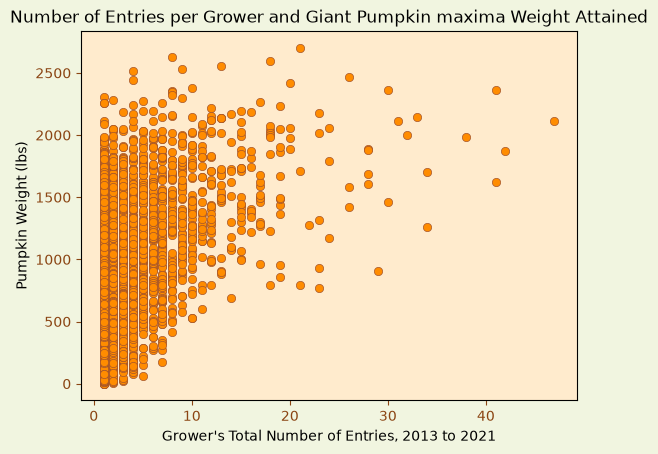

In [61]:
# maxima growers scatterplot: total number of entries over the years and max weight ever attained

plt.figure(figsize=(12, 5))
fig, ax = plt.subplots()

sns.scatterplot(
    data=growers_maxima_mean_max,
    x='total_entries',
    y='max_all_years',
    color='darkorange',
    edgecolor='sienna'
)
plt.title('Number of Entries per Grower and Giant Pumpkin maxima Weight Attained')
plt.xlabel("Grower's Total Number of Entries, 2013 to 2021")
plt.ylabel("Pumpkin Weight (lbs)")
fig.patch.set_facecolor('#F1F5E0')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
ax.set_facecolor('blanchedalmond')

plt.show()

## Cucurbita pepo Growers

In [51]:
# count of pumpkin entries each year by grower for Cucurbita pepo
pepo = big_pumpkin[big_pumpkin['Type'] == 'Cucurbita pepo']

growers_pepo = pepo.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='count'
)

growers_pepo = growers_pepo.reset_index()

# make column that shows sum of count of entries per year by grower
growers_pepo['total_entries'] = growers_pepo.sum(axis=1, numeric_only=True)

# rename year columns to be more descriptive
growers_pepo = growers_pepo.rename(
    columns={
        2013:'2013_entries',
        2014:'2014_entries',
        2015:'2015_entries', 
        2016:'2016_entries', 
        2017:'2017_entries', 
        2018:'2018_entries', 
        2019:'2019_entries', 
        2020:'2020_entries', 
        2021:'2021_entries'})

In [52]:
# mean pumpkin weight in lbs each year by grower for pepo
mean_weight_pepo = pepo.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='mean'
)

mean_weight_pepo = mean_weight_pepo.reset_index()

# make column that shows mean weight of pumpkins across all years by grower
mean_weight_pepo['mean_all_years'] = mean_weight_pepo.mean(axis=1, numeric_only=True)

# rename year columns to be more descriptive
mean_weight_pepo = mean_weight_pepo.rename(
    columns={
        2013:'2013_mean_wt_lb', 
        2014:'2014_mean_wt_lb', 
        2015:'2015_mean_wt_lb', 
        2016:'2016_mean_wt_lb', 
        2017:'2017_mean_wt_lb', 
        2018:'2018_mean_wt_lb', 
        2019:'2019_mean_wt_lb', 
        2020:'2020_mean_wt_lb', 
        2021:'2021_mean_wt_lb'})

In [53]:
# max pumpkin weight in lbs each year by grower for pepo
max_weight_pepo = pepo.pivot_table(
    index='grower_name',
    columns='year',
    values='weight_lbs',
    aggfunc='max'
)

max_weight_pepo = max_weight_pepo.reset_index()

# make column that shows max weight across all years by grower
max_weight_pepo['max_all_years'] = max_weight_pepo.max(axis=1, numeric_only=True)

# rename year columns to be more descriptive
max_weight_pepo = max_weight_pepo.rename(
    columns={
        2013:'2013_max_wt_lb', 
        2014:'2014_max_wt_lb', 
        2015:'2015_max_wt_lb', 
        2016:'2016_max_wt_lb', 
        2017:'2017_max_wt_lb', 
        2018:'2018_max_wt_lb', 
        2019:'2019_max_wt_lb', 
        2020:'2020_max_wt_lb', 
        2021:'2021_max_wt_lb'})

In [54]:
# Outer merge growers_pepo and mean_weight_pepo

growers_pepo_mean = pd.merge(growers_pepo, mean_weight_pepo, on='grower_name', how='outer')
growers_pepo_mean.shape

(1088, 21)

In [55]:
# Outer merge growers_pepo_mean and max_weight_pepo

growers_pepo_mean_max = pd.merge(growers_pepo_mean, max_weight_pepo, on='grower_name', how='outer')
growers_pepo_mean_max.shape

(1088, 31)

In [56]:
# Rank Cucurbita pepo growers by highest number of total entries and show top 5

pepo_growers_ranked = growers_pepo_mean_max.sort_values('total_entries', ascending=False)
pepo_growers_ranked[['grower_name','total_entries', 'mean_all_years','max_all_years']].head(5)

year,grower_name,total_entries,mean_all_years,max_all_years
952,"Treece, Jef",64.0,114.379153,188.5
725,"Paul, Michael",26.0,123.255952,177.0
891,"Steil, Scott",22.0,124.310884,197.5
385,"Harnica, John",21.0,102.930556,153.5
183,"Cleaview, Acres",19.0,91.580714,147.0


In [57]:
# Rank Cucurbita pepo growers by heaviest pumpkin entered (lbs) and show top 5

pepo_growers_heaviest = growers_pepo_mean_max.sort_values('max_all_years', ascending=False)
pepo_growers_heaviest[['grower_name','total_entries', 'mean_all_years','max_all_years']].head(5)

year,grower_name,total_entries,mean_all_years,max_all_years
578,"MacKinnon, John",11.0,155.889722,211.0
1053,"Wursten, Bradley",6.0,123.162500,205.0
690,"Nesbitt, Alan",2.0,182.750000,204.5
891,"Steil, Scott",22.0,124.310884,197.5
575,"MacKinnon , John",1.0,197.000000,197.0


<Figure size 1200x500 with 0 Axes>

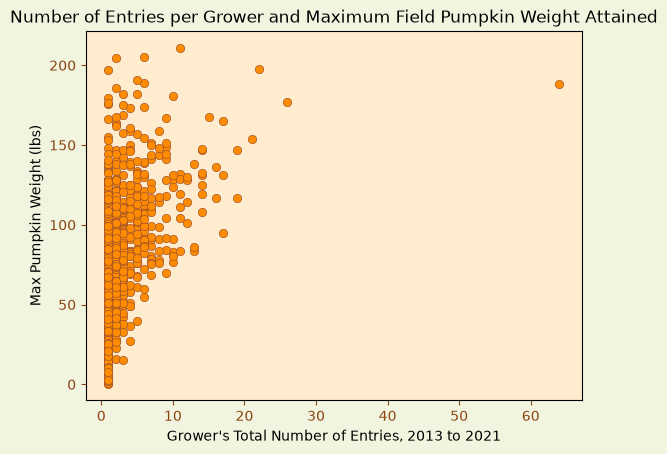

In [62]:
#pepo growers scatterplot: total number of entries over the years and max weight ever attained

plt.figure(figsize=(12, 5))
fig, ax = plt.subplots()

sns.scatterplot(
    data=growers_pepo_mean_max,
    x='total_entries',
    y='max_all_years',
    color='darkorange',
    edgecolor='sienna'
)
plt.title('Number of Entries per Grower and Maximum Field Pumpkin Weight Attained')
plt.xlabel("Grower's Total Number of Entries, 2013 to 2021")
plt.ylabel("Max Pumpkin Weight (lbs)")
fig.patch.set_facecolor('#F1F5E0')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
ax.set_facecolor('blanchedalmond')

plt.show()

## Pumpkin actual vs estimated weights

In [63]:
# the difference between actual weight and estimated weight

big_pumpkin['change'] = big_pumpkin['weight_lbs'] - big_pumpkin['est_weight']


In [64]:
# function determining the type of estimate
def weight_diff(change): 
    if -25 <= change <= 25: 
        return 'Excellent'
    elif (change >= -100 and change < -25) or (change <= 100 and change > 25):
        return 'Good'
    elif (change >= -300 and change < -100) or (change <= 300 and change > 100):
        return 'Moderate'
    elif (change >= -500 and change < -300) or (change <= 500 and change > 300):
        return 'Poor'
    else: 
        return 'Awful'

big_pumpkin['change_estimate_ranking'] = big_pumpkin['change'].apply(weight_diff)

In [66]:
# function determining if it's an over or underestimate
def over_under(change): 
    if change < 0: 
        return 'Under-estimate'
    elif change > 0:
        return 'Over-estimate'
    else: 
        return 'Perfect estimate!'

big_pumpkin['change_o_u'] = big_pumpkin['change'].apply(over_under)

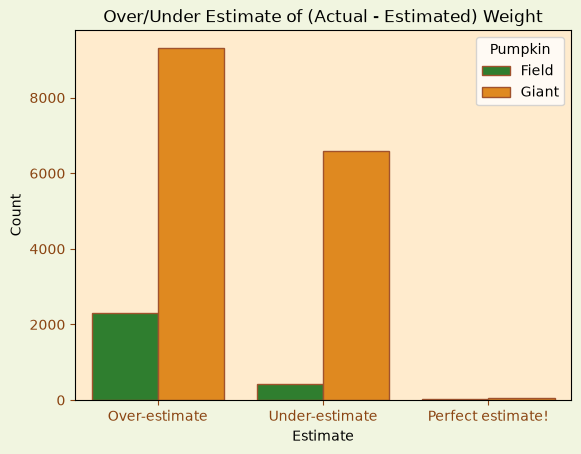

In [69]:
# graph for good/bad estimate
fig, ax = plt.subplots()
ax.set_facecolor('blanchedalmond')

sns.countplot(
    data = big_pumpkin, 
    x = 'change_o_u', 
    hue = 'Type', 
    palette=["forestgreen", "darkorange"], 
    edgecolor='sienna'
)
plt.xlabel('Estimate')
plt.ylabel('Count')
plt.title('Over/Under Estimate of (Actual - Estimated) Weight')

ax.legend(['Field', 'Giant'], title = 'Pumpkin')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
fig.patch.set_facecolor('#F1F5E0')
plt.show()

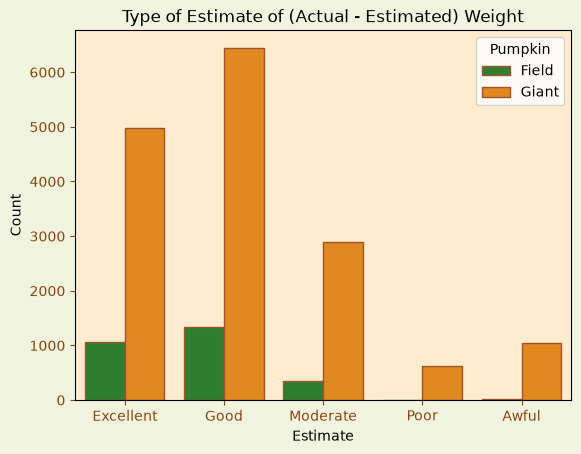

In [70]:
# graph for over/under estimate
custom_order = ['Excellent', 'Good', 'Moderate', 'Poor', 'Awful']

fig, ax = plt.subplots()
ax.set_facecolor('blanchedalmond')

sns.countplot(
    data = big_pumpkin, 
    x = 'change_estimate_ranking', 
    hue = 'Type', 
    order = custom_order, 
    palette=["forestgreen", "darkorange"], 
    edgecolor='sienna'
)
plt.xlabel('Estimate')
plt.ylabel('Count')
plt.title('Type of Estimate of (Actual - Estimated) Weight')

ax.legend(['Field', 'Giant'], title = 'Pumpkin')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
fig.patch.set_facecolor('#F1F5E0')
plt.show()

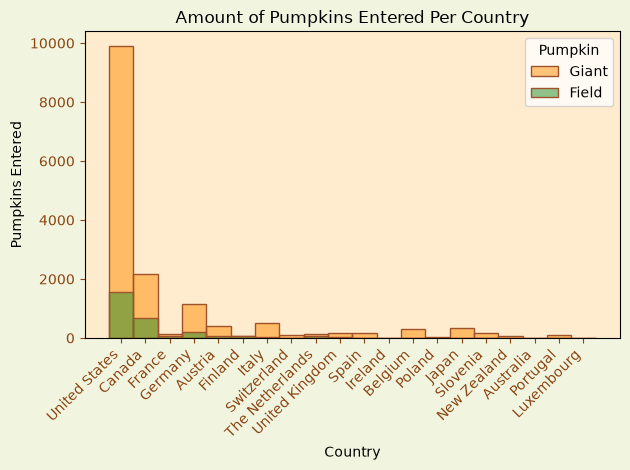

In [71]:
# graph of the number of pumpkins that were entered per country
fig, ax = plt.subplots()
ax.set_facecolor('blanchedalmond')

sns.histplot(
    data = big_pumpkin, 
    x = 'country', 
    hue = 'Type', 
    palette=["forestgreen", "darkorange"], 
    edgecolor='sienna'
)
plt.xlabel('Country', color='black')
plt.ylabel('Pumpkins Entered', color='black')
plt.title('Amount of Pumpkins Entered Per Country')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()

ax.legend(['Giant', 'Field'], title = 'Pumpkin')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
fig.patch.set_facecolor('#F1F5E0')
plt.show()

### US States

In [73]:
# new df with just us as the country
us_pumpkins = big_pumpkin[big_pumpkin['country'] == 'United States']

# new variable comparing the mean weights of each state
state_weight = us_pumpkins.groupby(['state_prov', 'Type'])['weight_lbs'].mean().sort_values(ascending = False).reset_index()
state_weight.round(2)

# new variable comparing the counts of pumpkins per state
state_count = us_pumpkins.groupby(['state_prov', 'Type'])['weight_lbs'].count().sort_values(ascending = False).reset_index()
state_count.round(2)

,state_prov,Type,weight_lbs
0,Wisconsin,Cucurbita maxima,1031
1,California,Cucurbita maxima,991
2,Ohio,Cucurbita maxima,713
3,Washington,Cucurbita maxima,711
4,Michigan,Cucurbita maxima,633
...,...,...,...
78,North Dakota,Cucurbita pepo,1
79,Montana,Cucurbita pepo,1
80,Nevada,Cucurbita pepo,1
81,Florida,Cucurbita maxima,1


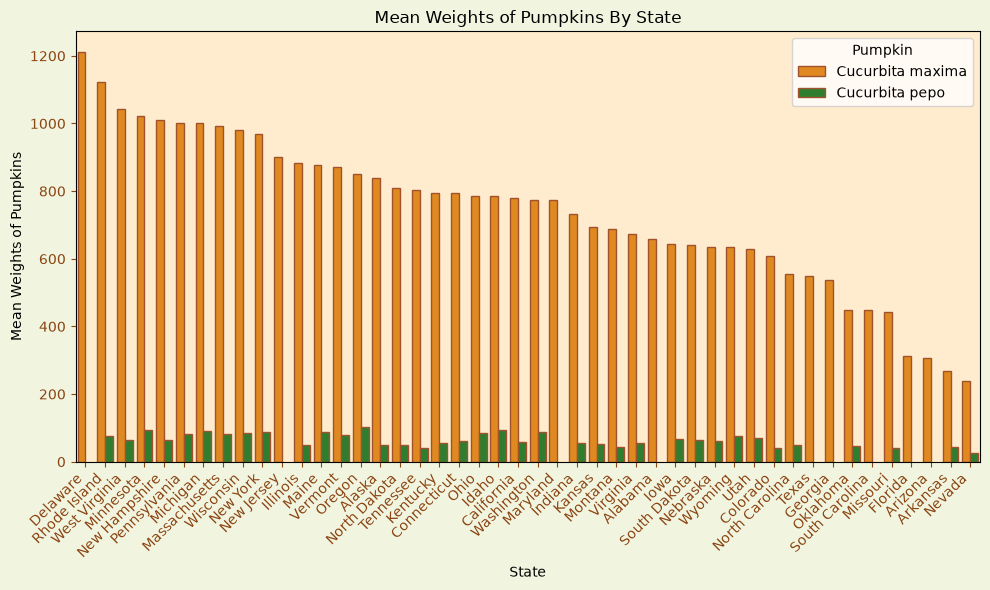

In [75]:
# graph of mean weights of pumpkins per state including type
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('blanchedalmond')

sns.barplot(
    data = state_weight, 
    x = 'state_prov', 
    y = 'weight_lbs', 
    hue = 'Type', 
    palette=['darkorange', 'forestgreen'], 
    edgecolor='sienna'
)
plt.xlabel('State')
plt.ylabel('Mean Weights of Pumpkins')
plt.title('Mean Weights of Pumpkins By State')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()

ax.legend(title = 'Pumpkin')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
fig.patch.set_facecolor('#F1F5E0')
plt.show()

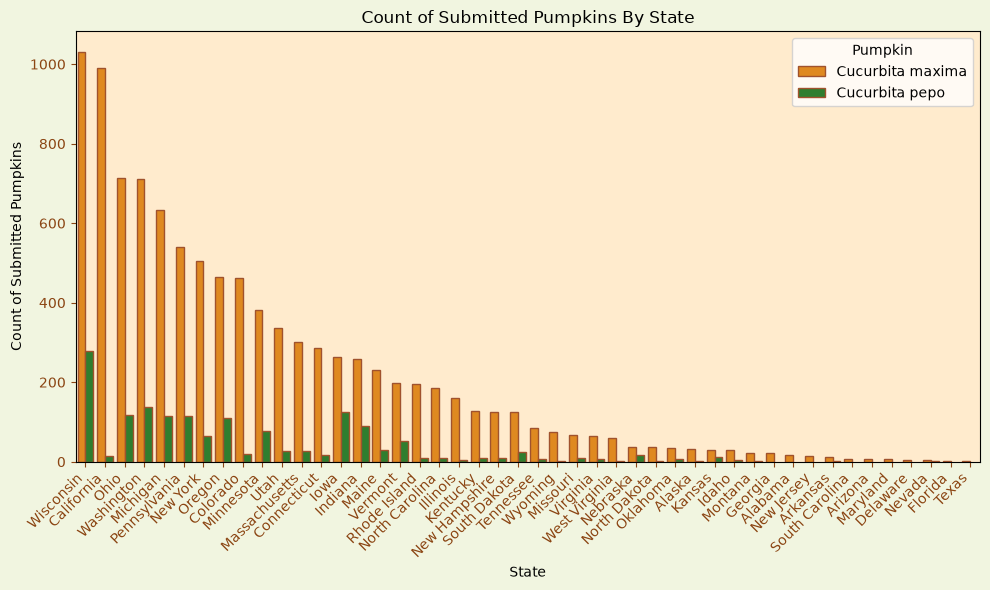

In [76]:
# graph of counts of pumpkins per state including type
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('blanchedalmond')

sns.barplot(
    data = state_count, 
    x = 'state_prov', 
    y = 'weight_lbs', 
    hue = 'Type', 
    palette=['darkorange', 'forestgreen'], 
    edgecolor='sienna'
)
plt.xlabel('State')
plt.ylabel('Count of Submitted Pumpkins')
plt.title('Count of Submitted Pumpkins By State')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()

ax.legend(title = 'Pumpkin')
ax.tick_params(axis='x', colors='saddlebrown')
ax.tick_params(axis='y', colors='saddlebrown')
fig.patch.set_facecolor('#F1F5E0')
plt.show()